# Healthcare Claims: Prediction + Weekly Forecast on ~10k Records

This notebook walks the full pipeline in `claims_ml.py`:

1. **Data** - a synthetic 10,000-claim CSV (replace with your own, same columns).
2. **Claim-level models** - P(denied) and paid-amount-if-approved, with every metric that matters.
3. **Weekly forecast** - total paid $ and claim count, 4 weeks ahead, with backtested intervals.
4. **The weekly learning loop** - replayed on history: predict a week, reveal it, score it, retrain.
5. **Is 10k rows enough?** - a learning curve answers it directly.

Everything reads and writes CSV files in this folder. No database. See `README.md` for the metric glossary and tuning guide.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import claims_ml as cm

pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40); pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
BLUE, ORANGE, AQUA, YELLOW, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#9a9a95"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": 0.6, "axes.edgecolor": "#c3c2b7",
                     "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold", "legend.frameon": False})

## 1. Data

In [2]:
if not cm.DATA.exists():
    cm.generate()
raw = cm.load()
df = cm.make_features(raw)
print(raw.shape, "| denial rate", f"{raw.is_denied.mean():.1%}", "| date range", raw.service_date.min().date(), "->", raw.service_date.max().date())
raw.head()

(10000, 26) | denial rate 12.5% | date range 2024-01-01 -> 2025-12-28


,claim_id,member_id,service_date,submitted_date,age,gender,plan_type,region,tenure_months,chronic_conditions,prior_claims_12m,prior_paid_12m,provider_specialty,place_of_service,diagnosis_group,procedure_group,in_network,is_emergency,prior_auth,length_of_stay,units,days_to_submit,deductible_remaining,billed_amount,is_denied,paid_amount
0,CLM008609,M00479,2024-01-01,2024-01-13,55,F,HMO,Southeast,90.000,2,5,"3,335.750",PrimaryCare,Outpatient,Pregnancy,Surgery,False,False,True,0,1,12,492.920,"16,208.230",1,0.000
1,CLM003347,M03583,2024-01-01,2024-01-07,57,M,PPO,Northeast,99.000,2,2,820.010,Cardiology,Pharmacy,Digestive,Drug,True,False,True,0,1,6,990.470,478.830,0,0.000
2,CLM003073,M03613,2024-01-01,2024-02-18,28,F,HMO,Northeast,64.000,1,1,191.670,Gastroenterology,Office,Injury,Evaluation,True,False,True,0,3,48,496.680,582.000,0,0.000
3,CLM005122,M00042,2024-01-01,2024-02-15,37,M,HMO,Midwest,76.000,0,2,"2,875.690",Orthopedics,Office,Other,Therapy,False,False,True,0,1,45,497.760,393.210,0,0.000
4,CLM000669,M03379,2024-01-01,2024-01-25,61,F,HMO,Southwest,71.000,0,3,"1,716.440",Orthopedics,Office,Digestive,Evaluation,True,False,True,0,1,24,495.760,167.870,0,0.000


In [3]:
approved = raw[raw.is_denied == 0]
approved.paid_amount.describe(percentiles=[.5, .9, .99]).to_frame("paid_amount (approved)").T

,count,mean,std,min,50%,90%,99%,max
paid_amount (approved),"8,751.000","1,819.997","7,893.845",0.000,172.910,"1,585.290","52,400.580","94,797.030"


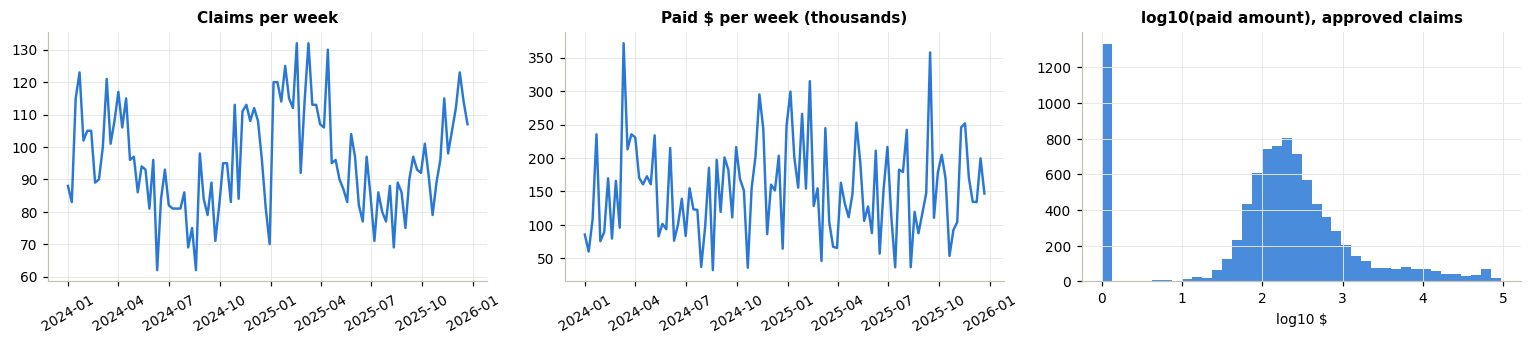

In [4]:
ws = cm.weekly_series(df)
fig, ax = plt.subplots(1, 3, figsize=(14, 3.2))
ax[0].plot(ws.index, ws.claims, color=BLUE, lw=1.6); ax[0].set_title("Claims per week")
ax[1].plot(ws.index, ws.paid / 1e3, color=BLUE, lw=1.6); ax[1].set_title("Paid $ per week (thousands)")
ax[2].hist(np.log10(approved.paid_amount.clip(lower=1)), bins=40, color=BLUE, alpha=.85); ax[2].set_title("log10(paid amount), approved claims")
ax[2].set_xlabel("log10 $")
for a in ax[:2]: a.tick_params(axis="x", rotation=30)
plt.tight_layout()

Notice: the weekly **count** is smooth (seasonal + trend), the weekly **dollars** are spiky. A handful of catastrophic claims dominate any given week's total. That single fact drives most of the forecasting decisions below.

## 2. Claim-level models

`cm.train()` does, in order:

* time-based split: the last 12 weeks are held out and never touched during model selection
* repeated 5-fold CV on the training part for each candidate (median baseline, ridge, random forest, extra trees, gradient boosting)
* random-search tuning of the boosted model, then a stacked ensemble of the top 3
* selection **by CV score only**; the holdout is reported for all candidates but never used to choose
* a conformal prediction interval calibrated on CV residuals, coverage verified on the holdout
* permutation importance on the holdout
* final refit on all rows, saved to `model_paid.joblib` / `model_denial.joblib`

`fast=True` skips tuning + repeats (about 20s instead of 70s). Run `python claims_ml.py train` from a terminal for the full version.

In [5]:
reg, clf = cm.train(fast=True)

train: 8757 claims before 2025-10-05 | holdout: 1243 claims (last 12 weeks)

[paid_amount] cross-validation (approved claims)
  baseline_median        MAE=  1767.29 +/- 118.13  R2=-0.044
  random_forest          MAE=   241.71 +/-   5.59  R2=0.970
  extra_trees            MAE=   247.75 +/-   7.51  R2=0.969
  hist_gbm               MAE=   244.38 +/-  28.17  R2=0.970
  stack(random_forest+hist_gbm+extra_trees)          MAE=   231.00

  -> selected by CV: stack

[paid_amount] holdout (last 12 weeks)
  baseline_median        MAE=  1648.51  WAPE=0.936  R2=-0.043  sMAPE=0.773
  random_forest          MAE=   234.75  WAPE=0.133  R2=0.969  sMAPE=0.125
  extra_trees            MAE=   243.15  WAPE=0.138  R2=0.969  sMAPE=0.125
  hist_gbm               MAE=   245.66  WAPE=0.140  R2=0.959  sMAPE=0.120
  stack                  MAE=   236.79  WAPE=0.134  R2=0.964  sMAPE=0.121
  smearing factor (bias correction): x1.018
  90% interval coverage on holdout: 94.7% (median width $117)

  top features: bille

In [6]:
cols = ["model", "MAE", "MAE_CI95_low", "MAE_CI95_high", "RMSE", "MedianAE", "WAPE", "sMAPE", "MAPE_y>=50", "R2", "Bias", "RMSLE", "Within10pct", "PI_coverage", "PI_median_width"]
reg[reg.split == "holdout"][cols].set_index("model")

,MAE,MAE_CI95_low,MAE_CI95_high,RMSE,MedianAE,WAPE,sMAPE,MAPE_y>=50,R2,Bias,RMSLE,Within10pct,PI_coverage,PI_median_width
model,,,,,,,,,,,,,,
baseline_median,"1,648.511","1,157.695","2,096.551","7,879.730",101.625,0.936,0.773,0.644,-0.043,"-1,595.447",1.513,0.078,NaN,NaN
random_forest,234.749,156.011,321.476,"1,363.945",21.472,0.133,0.125,0.123,0.969,-46.198,0.156,0.493,NaN,NaN
extra_trees,243.152,165.542,325.089,"1,366.415",21.646,0.138,0.125,0.123,0.969,-69.614,0.156,0.508,NaN,NaN
hist_gbm,245.658,157.973,340.937,"1,569.274",21.351,0.140,0.120,0.118,0.959,-109.859,0.149,0.510,NaN,NaN
stack,236.789,152.079,319.183,"1,465.018",21.874,0.134,0.121,0.118,0.964,-91.535,0.149,0.511,NaN,NaN
stack (final),231.727,148.704,313.928,"1,427.084",20.548,0.132,0.118,0.117,0.966,-61.827,0.146,0.520,0.947,116.525
stack expected_paid (all claims),780.456,571.467,"1,010.481","3,985.656",33.694,0.503,0.396,0.159,0.699,22.967,2.223,0.377,NaN,NaN


In [7]:
ccols = ["model", "PR_AUC", "ROC_AUC", "F1", "precision", "recall", "specificity", "balanced_accuracy", "MCC", "log_loss", "Brier", "ECE", "TP", "FP", "TN", "FN"]
clf[clf.split == "holdout"][ccols].set_index("model")

,PR_AUC,ROC_AUC,F1,precision,recall,specificity,balanced_accuracy,MCC,log_loss,Brier,ECE,TP,FP,TN,FN
model,,,,,,,,,,,,,,,
baseline_prior,0.119,0.500,0.000,0.000,0.000,1.000,0.500,0.000,0.365,0.105,0.007,0.000,0.000,"1,095.000",148.000
logistic,0.507,0.810,0.547,0.473,0.649,0.902,0.775,0.483,0.279,0.078,0.022,96.000,107.000,988.000,52.000
random_forest,0.506,0.804,0.521,0.441,0.635,0.891,0.763,0.452,0.283,0.079,0.024,94.000,119.000,976.000,54.000
hist_gbm,0.510,0.799,0.520,0.470,0.581,0.911,0.746,0.450,0.277,0.077,0.012,86.000,97.000,998.000,62.000


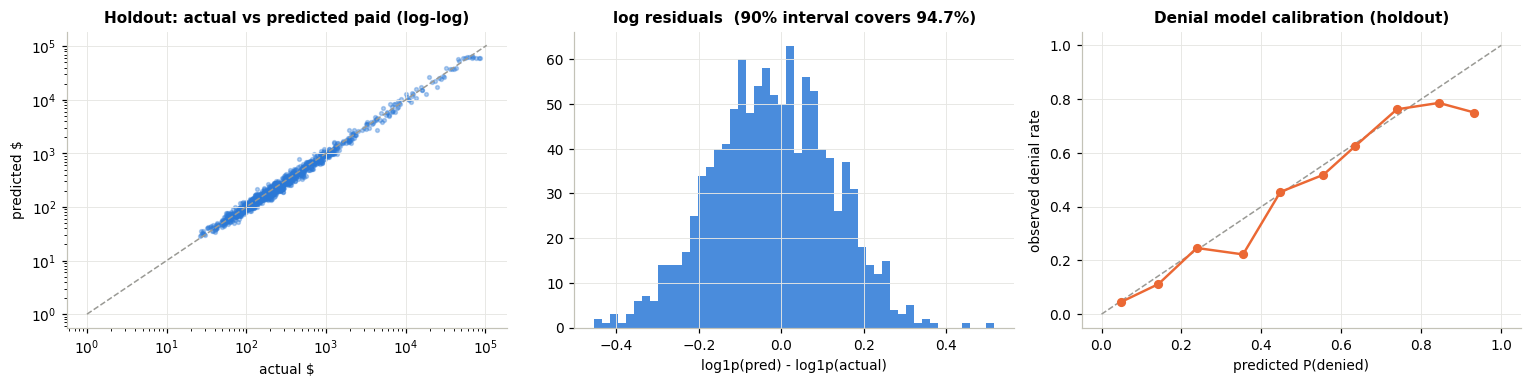

In [8]:
hp = pd.read_csv("holdout_predictions.csv")
a = hp[hp.actual_is_denied == 0]
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
ax[0].scatter(a.actual_paid.clip(lower=1), a.pred_paid_if_approved.clip(lower=1), s=6, alpha=.35, color=BLUE)
lim = [1, a.actual_paid.max() * 1.2]; ax[0].plot(lim, lim, color=GRAY, lw=1, ls="--")
ax[0].set_xscale("log"); ax[0].set_yscale("log"); ax[0].set_title("Holdout: actual vs predicted paid (log-log)"); ax[0].set_xlabel("actual $"); ax[0].set_ylabel("predicted $")
inside = (a.actual_paid >= a.pred_paid_low) & (a.actual_paid <= a.pred_paid_high)
ax[1].hist(np.log1p(a.pred_paid_if_approved) - np.log1p(a.actual_paid), bins=50, color=BLUE, alpha=.85)
ax[1].set_title(f"log residuals  (90% interval covers {inside.mean():.1%})"); ax[1].set_xlabel("log1p(pred) - log1p(actual)")
# denial calibration
b = pd.cut(hp.p_denied, np.linspace(0, 1, 11), include_lowest=True)
cal = hp.groupby(b, observed=True).agg(pred=("p_denied", "mean"), obs=("actual_is_denied", "mean"), n=("p_denied", "size"))
ax[2].plot([0, 1], [0, 1], color=GRAY, ls="--", lw=1); ax[2].plot(cal.pred, cal.obs, marker="o", ms=5, color=ORANGE, lw=1.6)
ax[2].set_title("Denial model calibration (holdout)"); ax[2].set_xlabel("predicted P(denied)"); ax[2].set_ylabel("observed denial rate")
plt.tight_layout()

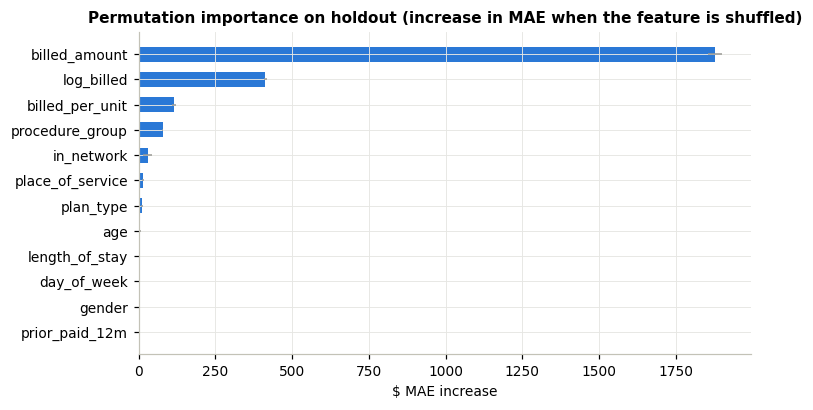

In [9]:
imp = pd.read_csv("feature_importance.csv").head(12)[::-1]
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.barh(imp.feature, imp.importance_mean, xerr=imp.importance_std, color=BLUE, height=0.6, error_kw=dict(ecolor=GRAY, lw=1))
ax.set_title("Permutation importance on holdout (increase in MAE when the feature is shuffled)"); ax.set_xlabel("$ MAE increase")
plt.tight_layout()

### Is 10,000 rows enough? A learning curve

Train the boosted model on 10%, 20%, ... 100% of the training rows and watch the CV error. If the curve is still falling steeply at 100%, more data would help a lot; if it has flattened, you are model-limited, not data-limited, and tuning/features matter more than collecting more rows.

,train_rows,cv_MAE,train_MAE
0,612,958.521,592.957
1,1399,430.107,346.954
2,2187,339.592,259.907
3,2974,275.994,229.398
4,3761,261.085,226.484
5,4549,252.550,222.357
6,5336,249.350,217.551
7,6124,241.217,215.886


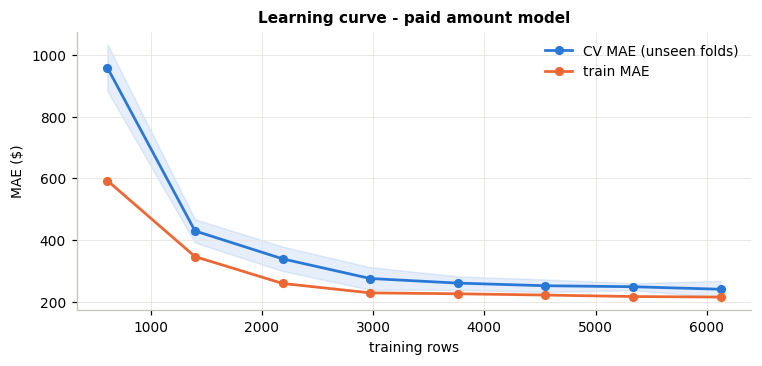

In [10]:
from sklearn.model_selection import learning_curve, KFold
from sklearn.pipeline import Pipeline
tr = df[(df.is_denied == 0) & (df.service_date < df.service_date.max() - pd.Timedelta(weeks=cm.HOLDOUT_WEEKS))]
est = cm.logt(Pipeline([("prep", cm.prep_ordinal()), ("m", cm.hgb_reg())]))
sizes, tr_s, te_s = learning_curve(est, tr[cm.FEATURES], tr[cm.TARGET_REG].values, train_sizes=np.linspace(0.1, 1.0, 8),
                                   cv=KFold(5, shuffle=True, random_state=cm.SEED), scoring="neg_mean_absolute_error", n_jobs=-1)
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(sizes, -te_s.mean(1), marker="o", ms=5, color=BLUE, lw=1.8, label="CV MAE (unseen folds)")
ax.fill_between(sizes, -te_s.mean(1) - te_s.std(1), -te_s.mean(1) + te_s.std(1), color=BLUE, alpha=.12)
ax.plot(sizes, -tr_s.mean(1), marker="o", ms=5, color=ORANGE, lw=1.8, label="train MAE")
ax.set_xlabel("training rows"); ax.set_ylabel("MAE ($)"); ax.set_title("Learning curve - paid amount model"); ax.legend()
plt.tight_layout()
lc = pd.DataFrame({"train_rows": sizes, "cv_MAE": -te_s.mean(1), "train_MAE": -tr_s.mean(1)}); lc.to_csv("learning_curve.csv", index=False); lc

## 3. Weekly forecast

`cm.forecast()` aggregates claims to complete weeks, then runs a **rolling-origin backtest**: 12 different "today" cut-offs, each forecasting 4 weeks ahead, for 7 candidate models. The winner by MAE gets an empirical prediction interval from its backtest residuals (coverage checked leave-one-origin-out) and is used for the next 4 weeks.

In [11]:
fm, bt, nxt = cm.forecast()

weekly history: 104 complete weeks  2024-01-01 .. 2025-12-22

[paid] rolling-origin backtest: 12 origins x 4 weeks ahead
         model        MAE        RMSE  MASE  WAPE  sMAPE  Bias_pct
      ensemble 38,107.800  51,001.241 0.480 0.236  0.258     0.012
seasonal_naive 42,319.595  55,149.108 0.533 0.262  0.291     0.027
      hgb_lags 49,980.521  62,042.957 0.630 0.309  0.324    -0.004
 ridge_fourier 53,496.396  64,936.046 0.674 0.331  0.350    -0.002
   holt_damped 56,800.349  72,134.821 0.715 0.351  0.365     0.004
 moving_avg_4w 66,155.286  84,156.288 0.833 0.409  0.420    -0.005
         naive 92,210.664 109,571.663 1.161 0.570  0.558     0.074
  -> best: ensemble   90% interval coverage (leave-one-origin-out): 85.4%

[claims] rolling-origin backtest: 12 origins x 4 weeks ahead
         model    MAE   RMSE  MASE  WAPE  sMAPE  Bias_pct
      ensemble  9.062 10.800 0.730 0.090  0.092    -0.007
 ridge_fourier  9.557 11.508 0.770 0.095  0.096     0.001
seasonal_naive  9.938 12.486 0.80

In [12]:
fm.set_index(["series", "model"])[["MAE", "RMSE", "MASE", "WAPE", "sMAPE", "MAPE", "Bias_pct", "MAE_h1", "MAE_h2", "MAE_h3", "MAE_h4", "PI90_coverage", "PI_median_width"]]

MAE        RMSE  MASE  WAPE  sMAPE  MAPE  Bias_pct     MAE_h1     MAE_h2      MAE_h3     MAE_h4  PI90_coverage  PI_median_width
series model                                                                                                                                                
paid   ensemble       38,107.800  51,001.241 0.480 0.236  0.258 0.291     0.012 48,547.573 34,805.387  34,111.566 34,966.676          0.854      139,281.927
       seasonal_naive 42,319.595  55,149.108 0.533 0.262  0.291 0.307     0.027 51,157.016 37,962.807  38,233.453 41,925.104            NaN              NaN
       hgb_lags       49,980.521  62,042.957 0.630 0.309  0.324 0.377    -0.004 59,364.214 41,443.425  49,190.302 49,924.141            NaN              NaN
       ridge_fourier  53,496.396  64,936.046 0.674 0.331  0.350 0.416    -0.002 63,388.970 48,830.975  49,119.569 52,646.071            NaN              NaN
       holt_damped    56,800.349  72,134.821 0.715 0.351  0.365 0.475     0.004 67,942.616 52,548.375  55,301.194 51,409.211            NaN              NaN
       moving_avg_4w  66,155.286  84,156.288 0.833 0.409  0.420 0.548    -0.005 74,115.470 62,174.691  63,919.255 64,411.727            NaN              NaN
       naive          92,210.664 109,571.663 1.161 0.570  0.558 0.684     0.074 84,849.954 94,027.928 101,611.777 88,352.997            NaN              NaN
claims ensemble            9.062      10.800 0.730 0.090  0.092 0.092    -0.007      8.421      8.999       9.009      9.818          0.854           36.397
       ridge_fourier       9.557      11.508 0.770 0.095  0.096 0.098     0.001      8.982      9.554       9.771      9.921            NaN              NaN
       seasonal_naive      9.938      12.486 0.801 0.099  0.102 0.101    -0.016      9.333      9.917       9.583     10.917            NaN              NaN
       naive              10.562      13.038 0.851 0.105  0.108 0.104    -0.046      9.167     10.667      10.750     11.667            NaN              NaN
       holt_damped        10.760      13.039 0.867 0.107  0.110 0.104    -0.080      8.282     10.568      11.859     12.331            NaN              NaN
       moving_avg_4w      10.906      13.154 0.879 0.109  0.111 0.106    -0.076      8.375     10.917      12.125     12.208            NaN              NaN
       hgb_lags           11.611      13.759 0.936 0.116  0.117 0.118     0.000     10.160     10.879      11.417     13.989            NaN              NaN

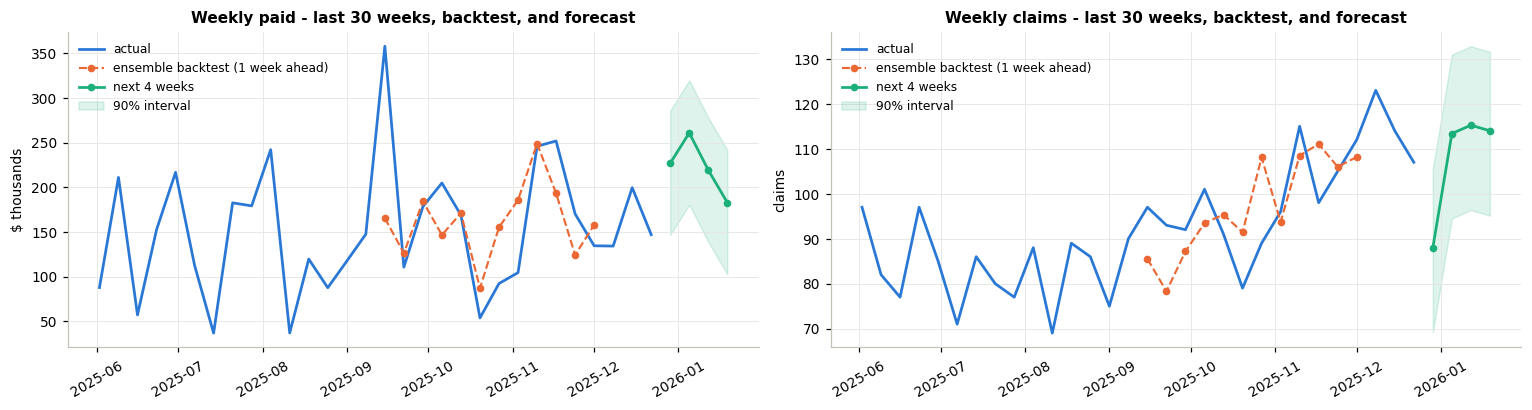

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
for ax, s, scale, unit in zip(axes, ["paid", "claims"], [1e3, 1], ["$ thousands", "claims"]):
    best = fm[fm.series == s].model.iloc[0]
    y = ws[s]
    hist = y.iloc[-30:]
    ax.plot(hist.index, hist / scale, color=BLUE, lw=1.8, label="actual")
    b1 = bt[(bt.series == s) & (bt.model == best) & (bt.step == 1)]
    ax.plot(y.index[b1.origin.values], b1.pred / scale, color=ORANGE, lw=1.4, ls="--", marker="o", ms=4, label=f"{best} backtest (1 week ahead)")
    n = nxt[nxt.series == s]; wk = pd.to_datetime(n.week_start)
    ax.plot(wk, n.forecast / scale, color=AQUA, lw=1.8, marker="o", ms=4, label="next 4 weeks")
    ax.fill_between(wk, n.low / scale, n.high / scale, color=AQUA, alpha=.15, label="90% interval")
    ax.set_title(f"Weekly {s} - last 30 weeks, backtest, and forecast"); ax.set_ylabel(unit); ax.legend(loc="upper left", fontsize=8); ax.tick_params(axis="x", rotation=30)
plt.tight_layout()

Reading this: the **count** series forecasts well (WAPE ~9%). The **dollar** series is much harder (WAPE ~24%) because catastrophic claims land randomly. Notice `seasonal_naive` (just "same week last year") is competitive with everything: with only two years of history, no model can learn much more than "this is what last year looked like". The ensemble of seasonal-naive + a Fourier-seasonal ridge is the best available. More history is the single biggest lever here.

## 4. The weekly learning loop, replayed

`cm.simulate(8)` walks the last 8 weeks one at a time. Each week it (a) forecasts that week's paid $ using only earlier data, (b) scores a claim-level model **retrained on everything before that week** against one **frozen 26 weeks earlier**, then reveals the week and moves on. This is exactly what `python claims_ml.py update new_week.csv` does in production, minus the CSV plumbing.

In [14]:
sim = cm.simulate(8)

simulating 8 weeks: 2025-11-03 .. 2025-12-22  (stale model frozen at 2025-05-05)
  2025-11-03  paid actual=   104,402 ens=   185,642 (77.8%)  claim MAE retrained=208 stale=213
  2025-11-10  paid actual=   245,841 ens=   248,770 (1.2%)  claim MAE retrained=237 stale=173
  2025-11-17  paid actual=   251,733 ens=   193,198 (23.3%)  claim MAE retrained=537 stale=578
  2025-11-24  paid actual=   170,150 ens=   124,213 (27.0%)  claim MAE retrained=277 stale=290
  2025-12-01  paid actual=   134,456 ens=   157,670 (17.3%)  claim MAE retrained=155 stale=190
  2025-12-08  paid actual=   134,108 ens=   163,252 (21.7%)  claim MAE retrained=94 stale=102
  2025-12-15  paid actual=   199,531 ens=   191,764 (3.9%)  claim MAE retrained=395 stale=397
  2025-12-22  paid actual=   146,872 ens=   137,918 (6.1%)  claim MAE retrained=175 stale=173

mean APE  ensemble=22.3%  seasonal_naive=32.1%  naive=26.9%
mean claim MAE  retrained weekly=259.82  stale 26w=264.61
saved learning_log_simulation.csv


,week_start,n_claims,actual_paid,forecast_ensemble,ape_ensemble,claim_WAPE_retrained_weekly,claim_WAPE_stale_26w
0,2025-11-03,96,"104,401.980","185,641.660",0.778,0.154,0.157
1,2025-11-10,115,"245,840.960","248,769.710",0.012,0.102,0.074
2,2025-11-17,98,"251,732.800","193,197.590",0.233,0.183,0.198
3,2025-11-24,105,"170,149.820","124,212.810",0.270,0.153,0.160
4,2025-12-01,112,"134,455.870","157,669.640",0.173,0.114,0.140
5,2025-12-08,123,"134,108.330","163,252.360",0.217,0.074,0.081
6,2025-12-15,114,"199,531.470","191,764.120",0.039,0.196,0.197
7,2025-12-22,107,"146,871.940","137,917.520",0.061,0.112,0.111


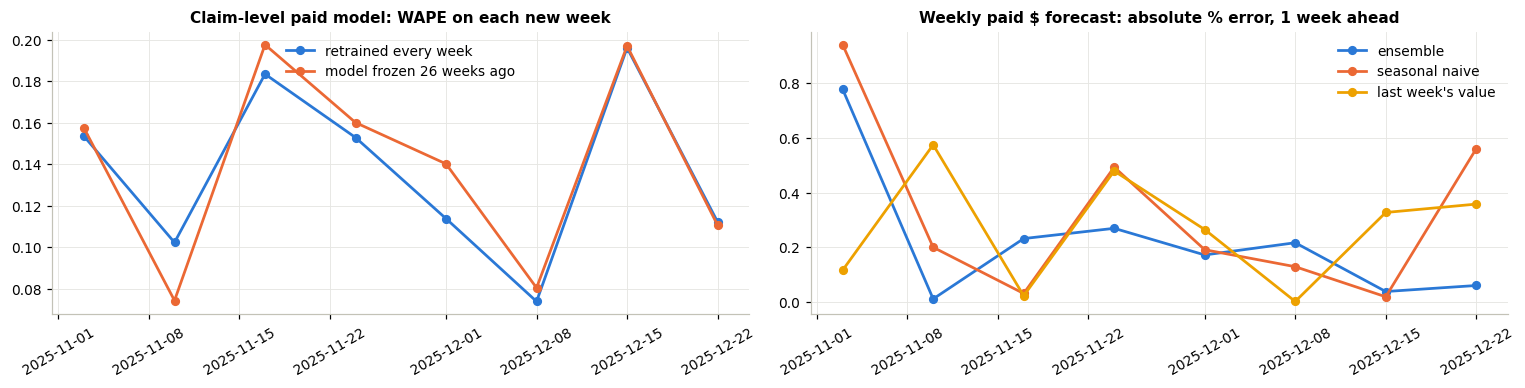

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(14, 3.6))
x = pd.to_datetime(sim.week_start)
ax[0].plot(x, sim.claim_WAPE_retrained_weekly, marker="o", ms=5, color=BLUE, lw=1.8, label="retrained every week")
ax[0].plot(x, sim.claim_WAPE_stale_26w, marker="o", ms=5, color=ORANGE, lw=1.8, label="model frozen 26 weeks ago")
ax[0].set_title("Claim-level paid model: WAPE on each new week"); ax[0].legend(); ax[0].tick_params(axis="x", rotation=30)
ax[1].plot(x, sim.ape_ensemble, marker="o", ms=5, color=BLUE, lw=1.8, label="ensemble")
ax[1].plot(x, sim.ape_seasonal_naive, marker="o", ms=5, color=ORANGE, lw=1.8, label="seasonal naive")
ax[1].plot(x, sim.ape_naive, marker="o", ms=5, color=YELLOW, lw=1.8, label="last week's value")
ax[1].set_title("Weekly paid $ forecast: absolute % error, 1 week ahead"); ax[1].legend(); ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
sim[["week_start", "n_claims", "actual_paid", "forecast_ensemble", "ape_ensemble", "claim_WAPE_retrained_weekly", "claim_WAPE_stale_26w"]]

**Honest reading of the loop result.** On this synthetic data a model frozen for six months is about as accurate as one retrained weekly, because the synthetic world drifts slowly (about 6%/yr in allowed ratios). That is not a reason to skip the loop. The loop's value is (1) a scored, dated record of how wrong you were each week, (2) drift detection (`drift_report.csv`) that tells you *when* retraining matters, and (3) a champion/challenger gate so a retrain can never silently make things worse. Real claims data drifts in steps (contract renegotiations, policy changes, a new provider group) and that is when the retrained line separates from the frozen one.

## 5. Using this on your data

1. Export your claims to `claims.csv` with the columns in README **Data dictionary** (one row per adjudicated claim).
2. `python claims_ml.py train` then `python claims_ml.py forecast`.
3. Each week: `python claims_ml.py update this_week.csv`.
4. Score open claims any time: `python claims_ml.py predict open_claims.csv`.

Tuning knobs are the CONFIG block at the top of `claims_ml.py`; the README explains what each one trades off.